# Portable Laptop QC + Analysis Notebook

This notebook is for **local inspection of HPC outputs** after you copy down the exported
`portable_laptop_bundle` folder from the cluster.

It is designed to:

- load exported tables and mask hyperstacks
- open the outputs in **napari**
- plot the main analysis results
- support light QC without rerunning the heavy model steps

## Expected bundle layout

```text
portable_laptop_bundle/
├── manifest.json
├── config/
│   └── pipeline_config.json
├── masks/
│   ├── segmentation_class_hyperstack.tif
│   ├── segmentation_label_hyperstack.tif
│   ├── nucleus_instance_hyperstack.tif
│   └── droplet_instance_hyperstack.tif
├── tables/
│   ├── best_z_nuclei.*
│   ├── best_z_nuclei_timed.*
│   ├── tracked_nuclei.*
│   ├── halo_analysis.*
│   └── ...
└── notes/
    └── README.txt
```

## Notes

- This notebook **does not rerun U-Net**.
- If you also want to overlay the **raw image**, either:
  - copy the raw TIFF locally and set `RAW_IMAGE_PATH`, or
  - place it somewhere accessible on your laptop and point the notebook to it.
- If probability maps were not exported, the notebook will skip them automatically.

In [1]:

from pathlib import Path
import json
import warnings

import numpy as np
import pandas as pd
import tifffile as tiff
import matplotlib.pyplot as plt

warnings.filterwarnings("ignore")

plt.rcParams["figure.figsize"] = (8, 4)
plt.rcParams["figure.dpi"] = 120

## 1. Set local paths

Update `BUNDLE_DIR` to the copied export folder on your laptop.

If you also copied the original raw TIFF locally, set `RAW_IMAGE_PATH`.
Otherwise leave it as `None`.

In [56]:

# --- USER SETTINGS ---
BUNDLE_DIR = Path(r"C:/Users/cowboy/OneDrive/Documents/University of Alabama/Nuclear_Scaling/Data_Sets/Control/portable_laptop_bundle")
RAW_IMAGE_PATH = Path(r"C:/Users/cowboy/OneDrive/Documents/University of Alabama/Nuclear_Scaling/Data_Sets/Control/Extract_1/control_extract_1.tif")  # Example: Path(r"C:/Users/cowboy/.../control_extract_1.1.tif")
AUTO_OPEN_NAPARI = True

## 2. Helper functions

In [8]:

def load_json(path: Path):
    with open(path, "r") as f:
        return json.load(f)

def first_existing(path_options):
    for p in path_options:
        if p is not None and Path(p).exists():
            return Path(p)
    return None

def load_table_prefer_parquet_csv_pickle(stem: Path):
    parquet_path = stem.with_suffix(".parquet")
    csv_path = stem.with_suffix(".csv")
    pkl_path = stem.with_suffix(".pkl")

    if parquet_path.exists():
        return pd.read_parquet(parquet_path), parquet_path
    if csv_path.exists():
        return pd.read_csv(csv_path), csv_path
    if pkl_path.exists():
        return pd.read_pickle(pkl_path), pkl_path

    return None, None

def safe_read_tiff(path: Path, memmap_preferred: bool = True):
    if path is None:
        return None

    path = Path(path)
    if not path.exists():
        return None

    if memmap_preferred:
        try:
            return tiff.memmap(path)
        except Exception:
            pass

    return tiff.imread(path)

def normalize_image(arr: np.ndarray):
    arr = arr.astype(np.float32)
    if arr.size == 0:
        return arr
    arr_min = np.nanmin(arr)
    arr_max = np.nanmax(arr)
    if arr_max > arr_min:
        arr = (arr - arr_min) / (arr_max - arr_min)
    return arr

def describe_df(df: pd.DataFrame, name: str):
    if df is None:
        print(f"{name}: missing")
        return
    print(f"{name}: shape={df.shape}")
    print(f"Columns: {list(df.columns)}")
    display(df.head())

def add_time_columns_if_missing(df: pd.DataFrame, cfg: dict):
    if df is None or df.empty:
        return df

    minutes_per_tile = cfg.get("minutes_per_tile", None)
    tile_rows = cfg.get("tile_rows", None)
    tile_cols = cfg.get("tile_cols", None)

    if "true_time_min" not in df.columns and "t" in df.columns and minutes_per_tile is not None:
        if tile_rows is not None and tile_cols is not None:
            tiles_per_cycle = max(int(tile_rows) * int(tile_cols), 1)
        else:
            tiles_per_cycle = 1
        df = df.copy()
        df["true_time_min"] = df["t"] * float(minutes_per_tile) * tiles_per_cycle

    return df

## 3. Load manifest, config, tables, and masks

In [9]:

bundle_dir = BUNDLE_DIR
assert bundle_dir.exists(), f"Bundle directory not found: {bundle_dir}"

manifest_path = bundle_dir / "manifest.json"
config_path = bundle_dir / "config" / "pipeline_config.json"
tables_dir = bundle_dir / "tables"
masks_dir = bundle_dir / "masks"

manifest = load_json(manifest_path) if manifest_path.exists() else {}
config = load_json(config_path) if config_path.exists() else {}

print("Bundle directory:", bundle_dir.resolve())
print("Manifest found:", manifest_path.exists())
print("Config found:", config_path.exists())

Bundle directory: C:\Users\cowboy\OneDrive\Documents\University of Alabama\Nuclear_Scaling\Data_Sets\Control\portable_laptop_bundle
Manifest found: True
Config found: True


In [ ]:
MIN_NUCLEUS_AREA_UM2_EARLY = 100
MIN_NUCLEUS_AREA_UM2_LATE = 250
MAX_NUCLEUS_AREA_UM2 = 450

MIN_CIRCULARITY_EARLY = 0.8
MIN_CIRCULARITY_LATE = 0.8

LATE_T_START = 4
EDGE_BUFFER_PX = 10

MAX_TRACKS_TO_PLOT = 75
SHOW_PLOT_LEGENDS = False

In [33]:
table_names = [
    "segmentation_index",
    "segmentation_index_portable",
    "plane_objects",
    "grouped_z_objects",
    "best_z_nuclei",
    "best_z_nuclei_cleaned",
    "best_z_nuclei_with_exclusion",
    "best_z_nuclei_timed",
    "tracked_nuclei",
    "halo_analysis",
]

tables = {}
table_sources = {}

for name in table_names:
    df, src = load_table_prefer_parquet_csv_pickle(tables_dir / name)
    tables[name] = df
    table_sources[name] = src

def apply_time_aware_cleaning(
    df: pd.DataFrame,
    min_area_um2_early: float = MIN_NUCLEUS_AREA_UM2_EARLY,
    min_area_um2_late: float = MIN_NUCLEUS_AREA_UM2_LATE,
    max_area_um2: float = MAX_NUCLEUS_AREA_UM2,
    min_circularity_early: float = MIN_CIRCULARITY_EARLY,
    min_circularity_late: float = MIN_CIRCULARITY_LATE,
    late_t_start: int = LATE_T_START,
    edge_buffer_px: int = EDGE_BUFFER_PX,
) -> pd.DataFrame:
    if df is None or df.empty:
        return df

    out = df.copy()

    if "nucleus_area_um2" in out.columns:
        t_series = out["t"] if "t" in out.columns else pd.Series(late_t_start, index=out.index)
        late_mask = t_series >= late_t_start
        area_keep = (
            (~late_mask & out["nucleus_area_um2"].between(min_area_um2_early, max_area_um2)) |
            (late_mask & out["nucleus_area_um2"].between(min_area_um2_late, max_area_um2))
        )
        out = out[area_keep].copy()

    if "circularity" in out.columns:
        t_series = out["t"] if "t" in out.columns else pd.Series(late_t_start, index=out.index)
        late_mask = t_series >= late_t_start
        circ_keep = (
            (~late_mask & (out["circularity"] >= min_circularity_early)) |
            (late_mask & (out["circularity"] >= min_circularity_late))
        )
        out = out[circ_keep].copy()

    if "is_edge_touching" in out.columns:
        edge_mask = out["is_edge_touching"].fillna(False).astype(bool)
        out = out[~edge_mask].copy()

    x_col = next((c for c in ["centroid_x", "x", "x_px"] if c in out.columns), None)
    y_col = next((c for c in ["centroid_y", "y", "y_px"] if c in out.columns), None)
    width_col = next((c for c in ["image_width_px", "width_px", "img_width_px"] if c in out.columns), None)
    height_col = next((c for c in ["image_height_px", "height_px", "img_height_px"] if c in out.columns), None)

    if x_col and y_col and width_col and height_col:
        out = out[
            (out[x_col] >= edge_buffer_px) &
            (out[y_col] >= edge_buffer_px) &
            (out[x_col] <= (out[width_col] - edge_buffer_px)) &
            (out[y_col] <= (out[height_col] - edge_buffer_px))
        ].copy()

    return out

seg_index_df = tables["segmentation_index_portable"] if tables["segmentation_index_portable"] is not None else tables["segmentation_index"]
objects_df = tables["plane_objects"]
grouped_z_df = tables["grouped_z_objects"]

for key in ["best_z_nuclei", "best_z_nuclei_cleaned", "best_z_nuclei_timed", "tracked_nuclei", "halo_analysis", "best_z_nuclei_with_exclusion"]:
    if tables.get(key) is not None:
        tables[key] = add_time_columns_if_missing(tables[key], config)

best_z_raw_df = tables["best_z_nuclei"]
cleaned_best_z_from_bundle_df = tables["best_z_nuclei_cleaned"]

if cleaned_best_z_from_bundle_df is not None:
    best_z_df = cleaned_best_z_from_bundle_df.copy()
    best_z_source_name = "best_z_nuclei_cleaned"
else:
    best_z_df = apply_time_aware_cleaning(best_z_raw_df)
    best_z_source_name = "best_z_nuclei (cleaned locally)"

filtered_df = tables["best_z_nuclei_with_exclusion"]
timed_df = tables["best_z_nuclei_timed"]
tracked_df = tables["tracked_nuclei"]
halo_df = tables["halo_analysis"]

if timed_df is not None and cleaned_best_z_from_bundle_df is None:
    timed_df = apply_time_aware_cleaning(timed_df)

if tracked_df is not None:
    tracked_df = apply_time_aware_cleaning(tracked_df)

if halo_df is not None:
    halo_df = apply_time_aware_cleaning(halo_df)

print(f"Best-Z table source in use: {best_z_source_name}")
if best_z_raw_df is not None and best_z_df is not None:
    print(f"Best-Z rows: raw={len(best_z_raw_df):,} -> active={len(best_z_df):,}")

Best-Z table source in use: best_z_nuclei (cleaned locally)
Best-Z rows: raw=19,443 -> active=19,443


In [34]:

mask_files = {
    "segmentation_class": first_existing([
        masks_dir / "segmentation_class_hyperstack.tif",
    ]),
    "segmentation_label": first_existing([
        masks_dir / "segmentation_label_hyperstack.tif",
    ]),
    "nucleus_instance": first_existing([
        masks_dir / "nucleus_instance_hyperstack.tif",
    ]),
    "droplet_instance": first_existing([
        masks_dir / "droplet_instance_hyperstack.tif",
    ]),
    "segmentation_prob": first_existing([
        masks_dir / "segmentation_prob_hyperstack.tif",   # future-proof if added later
        masks_dir / "probability_hyperstack.tif",
    ]),
}

mask_arrays = {name: safe_read_tiff(path) for name, path in mask_files.items()}

raw_img = None
if RAW_IMAGE_PATH is not None:
    raw_img = safe_read_tiff(Path(RAW_IMAGE_PATH), memmap_preferred=True)

    try:
        print("Raw image loaded lazily.")
        print("shape:", raw_img.shape)
        print("dtype:", raw_img.dtype)
    except Exception:
        print("Raw image path found, but shape could not be reported.")

Raw image loaded lazily.
shape: (10, 20, 3, 3889, 5732)
dtype: >u2


## 4. Quick bundle summary

In [35]:

print("=== TABLES ===")
for name, src in table_sources.items():
    exists = src is not None
    print(f"{name:30s} -> {'loaded from ' + str(src.name) if exists else 'missing'}")

print("\n=== MASKS ===")
for name, path in mask_files.items():
    arr = mask_arrays[name]
    shape = None if arr is None else arr.shape
    print(f"{name:30s} -> {path.name if path else 'missing'} | shape={shape}")

print("\n=== RAW IMAGE ===")
print("raw image loaded:", raw_img is not None)
if raw_img is not None:
    print("raw image shape:", raw_img.shape)

=== TABLES ===
segmentation_index             -> loaded from segmentation_index.csv
segmentation_index_portable    -> missing
plane_objects                  -> loaded from plane_objects.csv
grouped_z_objects              -> loaded from grouped_z_objects.csv
best_z_nuclei                  -> loaded from best_z_nuclei.csv
best_z_nuclei_cleaned          -> missing
best_z_nuclei_with_exclusion   -> loaded from best_z_nuclei_with_exclusion.csv
best_z_nuclei_timed            -> loaded from best_z_nuclei_timed.csv
tracked_nuclei                 -> loaded from tracked_nuclei.csv
halo_analysis                  -> loaded from halo_analysis.csv

=== MASKS ===
segmentation_class             -> segmentation_class_hyperstack.tif | shape=(10, 20, 3, 3889, 5732)
segmentation_label             -> segmentation_label_hyperstack.tif | shape=(10, 20, 3889, 5732)
nucleus_instance               -> nucleus_instance_hyperstack.tif | shape=(10, 20, 3889, 5732)
droplet_instance               -> droplet_instance_

## 5. Inspect main tables

In [36]:
describe_df(best_z_raw_df, "best_z_raw_df")
describe_df(best_z_df, "best_z_df_active")
describe_df(tracked_df, "tracked_df")
describe_df(halo_df, "halo_df")

best_z_raw_df: shape=(19443, 12)
Columns: ['t', 'z', 'label', 'centroid_x_px', 'centroid_y_px', 'area_px', 'bbox_min_row', 'bbox_min_col', 'bbox_max_row', 'bbox_max_col', 'nucleus_3d_id', 'true_time_min']


,t,z,label,centroid_x_px,centroid_y_px,area_px,bbox_min_row,bbox_min_col,bbox_max_row,bbox_max_col,nucleus_3d_id,true_time_min
0,0,0,1,2700.457035,63.320917,17235,1,2621,137,2777,1,0.0
1,0,0,2,1661.073895,70.521782,15265,3,1589,140,1736,2,0.0
2,0,0,3,5255.931032,76.739978,17037,4,5181,154,5332,3,0.0
3,0,0,4,4009.433078,58.652855,8495,5,3958,115,4063,4,0.0
4,0,0,5,2976.382765,115.093851,12637,45,2913,183,3042,5,0.0


best_z_df_active: shape=(19443, 12)
Columns: ['t', 'z', 'label', 'centroid_x_px', 'centroid_y_px', 'area_px', 'bbox_min_row', 'bbox_min_col', 'bbox_max_row', 'bbox_max_col', 'nucleus_3d_id', 'true_time_min']


,t,z,label,centroid_x_px,centroid_y_px,area_px,bbox_min_row,bbox_min_col,bbox_max_row,bbox_max_col,nucleus_3d_id,true_time_min
0,0,0,1,2700.457035,63.320917,17235,1,2621,137,2777,1,0.0
1,0,0,2,1661.073895,70.521782,15265,3,1589,140,1736,2,0.0
2,0,0,3,5255.931032,76.739978,17037,4,5181,154,5332,3,0.0
3,0,0,4,4009.433078,58.652855,8495,5,3958,115,4063,4,0.0
4,0,0,5,2976.382765,115.093851,12637,45,2913,183,3042,5,0.0


tracked_df: shape=(19443, 25)
Columns: ['t', 'z', 'label', 'centroid_x_px', 'centroid_y_px', 'area_px', 'bbox_min_row', 'bbox_min_col', 'bbox_max_row', 'bbox_max_col', 'nucleus_3d_id', 'valid_single_nucleus', 'tile_row', 'tile_col', 'tile_index', 'tile_offset_min', 'true_time_min', 'global_index', 'track_id', 'track_link_distance_px', 'track_link_cost', 'track_dbscan_cluster_id', 'track_dbscan_cluster_size', 'track_dbscan_is_crowded', 'track_link_method']


,t,z,label,centroid_x_px,centroid_y_px,area_px,bbox_min_row,bbox_min_col,bbox_max_row,bbox_max_col,...,tile_offset_min,true_time_min,global_index,track_id,track_link_distance_px,track_link_cost,track_dbscan_cluster_id,track_dbscan_cluster_size,track_dbscan_is_crowded,track_link_method
0,0,0,1,2700.457035,63.320917,17235,1,2621,137,2777,...,1.0,1.0,0,1,NaN,NaN,-1,0,False,seed
1,0,0,2,1661.073895,70.521782,15265,3,1589,140,1736,...,0.0,0.0,1,2,NaN,NaN,-1,0,False,seed
2,0,0,3,5255.931032,76.739978,17037,4,5181,154,5332,...,2.0,2.0,2,3,NaN,NaN,-1,0,False,seed
3,0,0,4,4009.433078,58.652855,8495,5,3958,115,4063,...,2.0,2.0,3,4,NaN,NaN,-1,0,False,seed
4,0,0,5,2976.382765,115.093851,12637,45,2913,183,3042,...,1.0,1.0,4,5,NaN,NaN,-1,0,False,seed


halo_df: shape=(673, 62)
Columns: ['t', 'z', 'label', 'centroid_x_px', 'centroid_y_px', 'area_px', 'bbox_min_row', 'bbox_min_col', 'bbox_max_row', 'bbox_max_col', 'nucleus_3d_id', 'valid_single_nucleus', 'tile_row', 'tile_col', 'tile_index', 'tile_offset_min', 'true_time_min', 'global_index', 'track_id', 'track_link_distance_px', 'track_link_cost', 'track_dbscan_cluster_id', 'track_dbscan_cluster_size', 'track_dbscan_is_crowded', 'track_link_method', 'nucleus_area_px', 'nucleus_intden', 'nucleus_mean_intensity', 'nucleus_eroded_area_px', 'nucleus_eroded_intden', 'nucleus_eroded_mean_intensity', 'halo_1_cum_area_px', 'halo_1_cum_intden', 'halo_1_cum_mean_intensity', 'halo_2_cum_area_px', 'halo_2_cum_intden', 'halo_2_cum_mean_intensity', 'halo_3_cum_area_px', 'halo_3_cum_intden', 'halo_3_cum_mean_intensity', 'halo_4_cum_area_px', 'halo_4_cum_intden', 'halo_4_cum_mean_intensity', 'ring_1_area_px', 'ring_1_intden', 'ring_1_mean_intensity', 'ring_2_area_px', 'ring_2_intden', 'ring_2_mean_in

,t,z,label,centroid_x_px,centroid_y_px,area_px,bbox_min_row,bbox_min_col,bbox_max_row,bbox_max_col,...,ring_4_area_px,ring_4_intden,ring_4_mean_intensity,cytoplasm_area_px,cytoplasm_intden,cytoplasm_mean_intensity,nc_ratio,nc_ratio_fraction,nucleus_area_um2,cytoplasm_area_um2
0,0,0,1,2700.457035,63.320917,17235,1,2621,137,2777,...,1721,345047.0,200.492156,6756,1474269.0,218.216252,1.476644,0.596228,201.029040,78.801984
1,0,0,2,1661.073895,70.521782,15265,3,1589,140,1736,...,1851,349774.0,188.964884,7402,1479931.0,199.936639,1.324211,0.569747,178.050960,86.336928
2,0,0,3,5255.931032,76.739978,17037,4,5181,154,5332,...,1954,372813.0,190.794780,7986,1626352.0,203.650388,1.386602,0.580994,198.719568,93.148704
4,0,0,5,2976.382765,115.093851,12637,45,2913,183,3042,...,2072,466620.0,225.202703,7670,1848205.0,240.965450,1.319510,0.568875,147.397968,89.462880
5,0,0,6,255.927505,135.625229,16346,61,183,214,331,...,2311,470400.0,203.548248,8549,1868082.0,218.514680,1.356250,0.575597,190.659744,99.715536


## 6. Plot helpers

In [37]:
def plot_counts_by_time(df: pd.DataFrame, title="Object count by time"):
    if df is None or df.empty or "t" not in df.columns:
        print("Missing required table/column for counts-by-time plot.")
        return

    plot_df = df.copy()
    if "true_time_min" in plot_df.columns:
        x = plot_df.groupby("true_time_min").size().reset_index(name="count")
        xlabel = "True time (min)"
        xcol = "true_time_min"
    else:
        x = plot_df.groupby("t").size().reset_index(name="count")
        xlabel = "Time index"
        xcol = "t"

    plt.figure()
    plt.plot(x[xcol], x["count"], marker="o")
    plt.xlabel(xlabel)
    plt.ylabel("Count")
    plt.title(title)
    plt.tight_layout()
    plt.show()

def plot_area_distribution(df: pd.DataFrame, area_col="area_px", title="Area distribution"):
    if df is None or df.empty or area_col not in df.columns:
        print(f"Missing required column: {area_col}")
        return

    vals = pd.to_numeric(df[area_col], errors="coerce").dropna()
    if vals.empty:
        print("No valid values to plot.")
        return

    plt.figure()
    plt.hist(vals, bins=40)
    plt.xlabel(area_col)
    plt.ylabel("Frequency")
    plt.title(title)
    plt.tight_layout()
    plt.show()

def _choose_time_column(df: pd.DataFrame):
    if "true_time_min" in df.columns:
        return "true_time_min", "True time (min)"
    if "t" in df.columns:
        return "t", "Time index"
    return None, None

def plot_area_vs_time(df: pd.DataFrame, area_col_candidates=("nucleus_area_um2", "area_um2", "area_px"), group_col="track_id", max_tracks=MAX_TRACKS_TO_PLOT):
    if df is None or df.empty:
        print("No data to plot.")
        return

    area_col = next((c for c in area_col_candidates if c in df.columns), None)
    if area_col is None:
        print("No supported area column found.")
        return

    xcol, xlabel = _choose_time_column(df)
    if xcol is None:
        print("No time column found.")
        return

    plt.figure()
    if group_col in df.columns:
        track_ids = pd.Series(df[group_col].dropna().unique())
        if len(track_ids) > max_tracks:
            track_ids = track_ids.iloc[:max_tracks]
        plot_df = df[df[group_col].isin(track_ids)].copy()

        for _, sub in plot_df.groupby(group_col):
            sub = sub.sort_values(xcol)
            plt.plot(sub[xcol], sub[area_col], marker="o", linewidth=1, alpha=0.8)

        plt.title(f"{area_col} vs time (sampled tracks, n={plot_df[group_col].nunique()})")
    else:
        sub = df.sort_values(xcol)
        plt.plot(sub[xcol], sub[area_col], marker="o")
        plt.title(f"{area_col} vs time")

    plt.xlabel(xlabel)
    plt.ylabel(area_col)
    plt.tight_layout()
    plt.show()

def plot_area_summary_vs_time(df: pd.DataFrame, area_col_candidates=("nucleus_area_um2", "area_um2", "area_px")):
    if df is None or df.empty:
        print("No data to plot.")
        return

    area_col = next((c for c in area_col_candidates if c in df.columns), None)
    if area_col is None:
        print("No supported area column found.")
        return

    xcol, xlabel = _choose_time_column(df)
    if xcol is None:
        print("No time column found.")
        return

    summary = (
        df[[xcol, area_col]]
        .dropna()
        .groupby(xcol)[area_col]
        .agg(["median", "mean", "std"])
        .reset_index()
    )

    plt.figure()
    plt.plot(summary[xcol], summary["mean"], marker="o", label="mean")
    plt.plot(summary[xcol], summary["median"], marker="s", label="median")
    plt.xlabel(xlabel)
    plt.ylabel(area_col)
    plt.title(f"{area_col} summary vs time")
    if SHOW_PLOT_LEGENDS:
        plt.legend()
    plt.tight_layout()
    plt.show()

def plot_nc_vs_time(halo_df: pd.DataFrame, y_col="nc_ratio_fraction", group_col="track_id", max_tracks=MAX_TRACKS_TO_PLOT):
    if halo_df is None or halo_df.empty:
        print("No halo data to plot.")
        return
    if y_col not in halo_df.columns:
        print(f"Column not found: {y_col}")
        return

    xcol, xlabel = _choose_time_column(halo_df)
    if xcol is None:
        print("No time column found.")
        return

    plt.figure()
    if group_col in halo_df.columns:
        track_ids = pd.Series(halo_df[group_col].dropna().unique())
        if len(track_ids) > max_tracks:
            track_ids = track_ids.iloc[:max_tracks]
        plot_df = halo_df[halo_df[group_col].isin(track_ids)].copy()

        for _, sub in plot_df.groupby(group_col):
            sub = sub.sort_values(xcol)
            plt.plot(sub[xcol], sub[y_col], marker="o", linewidth=1, alpha=0.8)

        plt.title(f"{y_col} vs time (sampled tracks, n={plot_df[group_col].nunique()})")
    else:
        sub = halo_df.sort_values(xcol)
        plt.plot(sub[xcol], sub[y_col], marker="o")
        plt.title(f"{y_col} vs time")

    plt.xlabel(xlabel)
    plt.ylabel(y_col)
    plt.tight_layout()
    plt.show()

def plot_nc_summary_vs_time(df: pd.DataFrame, y_col="nc_ratio_fraction"):
    if df is None or df.empty or y_col not in df.columns:
        print(f"Missing required column: {y_col}")
        return

    xcol, xlabel = _choose_time_column(df)
    if xcol is None:
        print("No time column found.")
        return

    summary = (
        df[[xcol, y_col]]
        .dropna()
        .groupby(xcol)[y_col]
        .agg(["median", "mean", "std"])
        .reset_index()
    )

    plt.figure()
    plt.plot(summary[xcol], summary["mean"], marker="o", label="mean")
    plt.plot(summary[xcol], summary["median"], marker="s", label="median")
    plt.xlabel(xlabel)
    plt.ylabel(y_col)
    plt.title(f"{y_col} summary vs time")
    if SHOW_PLOT_LEGENDS:
        plt.legend()
    plt.tight_layout()
    plt.show()

def plot_metric_histogram(df: pd.DataFrame, col: str, bins=40):
    if df is None or df.empty or col not in df.columns:
        print(f"Missing required column: {col}")
        return

    vals = pd.to_numeric(df[col], errors="coerce").dropna()
    if vals.empty:
        print("No valid values to plot.")
        return

    plt.figure()
    plt.hist(vals, bins=bins)
    plt.xlabel(col)
    plt.ylabel("Frequency")
    plt.title(f"{col} distribution")
    plt.tight_layout()
    plt.show()

def summarize_time_table(df: pd.DataFrame, name: str):
    if df is None or df.empty:
        print(f"{name}: empty or missing")
        return

    print(f"\n{name}")
    print("-" * len(name))
    if "t" in df.columns:
        print("n timepoints:", df["t"].nunique())
        print("time range:", int(df["t"].min()), "to", int(df["t"].max()))
    if "track_id" in df.columns:
        print("n tracks:", df["track_id"].nunique())
    if "label" in df.columns:
        print("n labels:", df["label"].nunique())
    print("rows:", len(df))
def plot_max_cross_sectional_area_scatter(
    df: pd.DataFrame,
    time_col: str = "true_time_min",
    area_col: str = "nucleus_area_um2",
    title: str = "Maximal cross-sectional area vs time",
) -> None:
    if df is None or df.empty:
        print("No data to plot.")
        return

    required = [time_col, area_col]
    missing = [c for c in required if c not in df.columns]
    if missing:
        print(f"Missing required columns: {missing}")
        return

    plot_df = df[[time_col, area_col]].dropna().copy()

    plt.figure(figsize=(8, 4.5))
    plt.scatter(
        plot_df[time_col],
        plot_df[area_col],
        s=20,
        alpha=0.7,
    )
    plt.xlabel("True time (min)")
    plt.ylabel("Max cross-sectional area (µm²)")
    plt.title(title)
    plt.tight_layout()
    plt.show()


## 7. Summary stats

In [42]:
def assign_fov_from_x(df, n_fov=6):
    df = df.copy()

    max_x = df["centroid_x_px"].max()
    fov_width = max_x / n_fov

    df["fov_id"] = (df["centroid_x_px"] // fov_width).astype(int)
    df["fov_id"] = df["fov_id"].clip(0, n_fov - 1)

    return df
def reconstruct_true_time(df, frame_interval_min=6):
    df = df.copy()

    if "fov_id" not in df.columns:
        raise ValueError("Missing fov_id")

    df["true_time_min"] = df["t"] * frame_interval_min + df["fov_id"]

    return df

In [48]:
df = assign_fov_from_x(best_z_df, n_fov=6)
df = reconstruct_true_time(df, frame_interval_min=6)

In [38]:
summarize_time_table(best_z_raw_df, "best_z_raw_df")
summarize_time_table(best_z_df, "best_z_df_active")
summarize_time_table(timed_df, "timed_df")
summarize_time_table(tracked_df, "tracked_df")
summarize_time_table(halo_df, "halo_df")


best_z_raw_df
-------------
n timepoints: 10
time range: 0 to 9
n labels: 222
rows: 19443

best_z_df_active
----------------
n timepoints: 10
time range: 0 to 9
n labels: 222
rows: 19443

timed_df
--------
n timepoints: 10
time range: 0 to 9
n labels: 222
rows: 19443

tracked_df
----------
n timepoints: 10
time range: 0 to 9
n tracks: 19443
n labels: 222
rows: 19443

halo_df
-------
n timepoints: 10
time range: 0 to 9
n tracks: 673
n labels: 174
rows: 673


In [41]:
print(best_z_df.columns)

Index(['t', 'z', 'label', 'centroid_x_px', 'centroid_y_px', 'area_px',
       'bbox_min_row', 'bbox_min_col', 'bbox_max_row', 'bbox_max_col',
       'nucleus_3d_id', 'true_time_min'],
      dtype='object')


## 8. Core plots

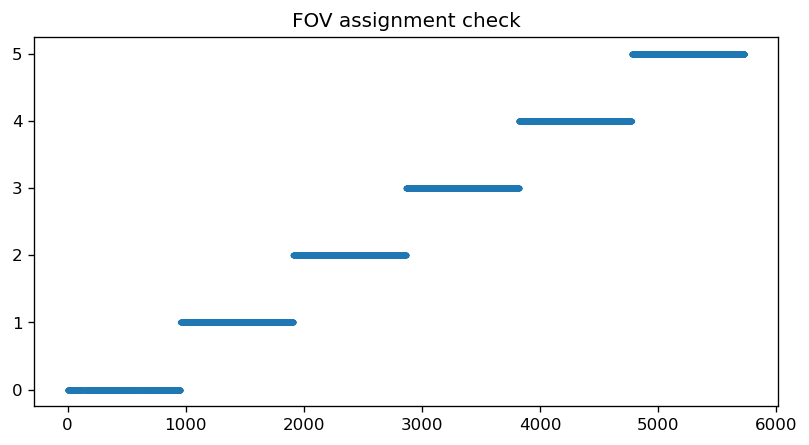

In [46]:
import matplotlib.pyplot as plt

plt.scatter(df["centroid_x_px"], df["fov_id"], s=5)
plt.title("FOV assignment check")
plt.show()

In [50]:
import matplotlib.pyplot as plt
import pandas as pd


def plot_max_cross_sectional_area_scatter(
    df: pd.DataFrame,
    pixel_size_um: float,
    n_fov: int = 6,
    serpentine: bool = True,
    area_px_col: str = "area_px",
    area_um2_col: str = "nucleus_area_um2",
):
    if df is None or df.empty:
        print("No data to plot.")
        return

    df = df.copy()

    # --- Convert area ---
    if area_um2_col not in df.columns:
        if area_px_col in df.columns:
            df[area_um2_col] = df[area_px_col] * (pixel_size_um ** 2)
        else:
            raise ValueError("Missing area column")

    # --- Assign FOV based on X ---
    max_x = df["centroid_x_px"].max()
    fov_width = max_x / n_fov

    df["fov_id"] = (df["centroid_x_px"] // fov_width).astype(int)
    df["fov_id"] = df["fov_id"].clip(0, n_fov - 1)

    # --- Serpentine correction ---
    if serpentine:
        reverse_mask = df["t"] % 2 == 1
        df.loc[reverse_mask, "fov_id"] = (n_fov - 1) - df.loc[reverse_mask, "fov_id"]

    # --- Reconstruct true time ---
    df["true_time_min"] = df["t"] * n_fov + df["fov_id"]

    print("Unique reconstructed times:")
    print(sorted(df["true_time_min"].unique())[:20])

    # --- Plot ---
    plt.figure(figsize=(8, 4.5))
    plt.scatter(
        df["true_time_min"],
        df[area_um2_col],
        s=20,
        alpha=0.6,
    )

    plt.xlabel("Time (min)")
    plt.ylabel("Max cross-sectional area (µm²)")
    plt.title("Max cross-sectional area vs time (reconstructed)")
    plt.tight_layout()
    plt.show()

Unique reconstructed times:
[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19]


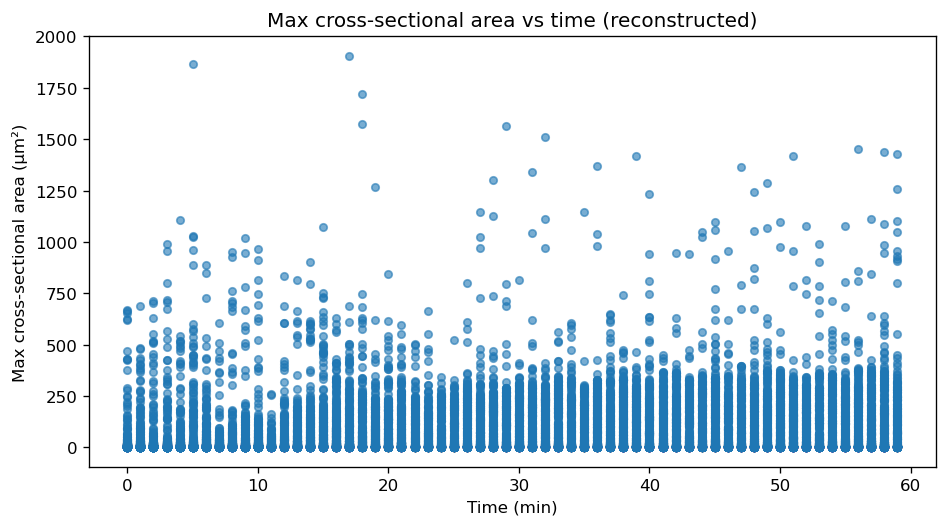

In [51]:
plot_max_cross_sectional_area_scatter(
    best_z_df,
    pixel_size_um=0.162,
    n_fov=6,
    serpentine=True
)

In [52]:
import matplotlib.pyplot as plt
import pandas as pd


def plot_max_cross_sectional_area_scatter(
    df: pd.DataFrame,
    pixel_size_um: float,
    n_fov: int = 6,
    serpentine: bool = True,
    area_px_col: str = "area_px",
    area_um2_col: str = "nucleus_area_um2",
    early_t_max: int = 4,
    early_min_area_um2: float = 50,
    early_max_area_um2: float = 200,
    late_min_area_um2: float = 100,
    late_max_area_um2: float = 500,
    title: str = "Max cross-sectional area vs time (reconstructed, filtered)",
):
    if df is None or df.empty:
        print("No data to plot.")
        return

    df = df.copy()

    # --- Convert area to µm² if needed ---
    if area_um2_col not in df.columns:
        if area_px_col in df.columns:
            df[area_um2_col] = df[area_px_col] * (pixel_size_um ** 2)
        else:
            raise ValueError(f"Missing both '{area_um2_col}' and '{area_px_col}'")

    # --- Assign FOV from x-position ---
    max_x = df["centroid_x_px"].max()
    fov_width = max_x / n_fov

    df["fov_id"] = (df["centroid_x_px"] // fov_width).astype(int)
    df["fov_id"] = df["fov_id"].clip(0, n_fov - 1)

    # --- Correct for serpentine ordering ---
    if serpentine:
        reverse_mask = df["t"] % 2 == 1
        df.loc[reverse_mask, "fov_id"] = (n_fov - 1) - df.loc[reverse_mask, "fov_id"]

    # --- Reconstruct true minute-level time ---
    df["true_time_min"] = df["t"] * n_fov + df["fov_id"]

    # --- Time-aware biological filtering ---
    early_mask = df["t"] <= early_t_max
    late_mask = df["t"] > early_t_max

    keep_early = (
        (df[area_um2_col] >= early_min_area_um2) &
        (df[area_um2_col] <= early_max_area_um2)
    )

    keep_late = (
        (df[area_um2_col] >= late_min_area_um2) &
        (df[area_um2_col] <= late_max_area_um2)
    )

    df_filtered = df[(early_mask & keep_early) | (late_mask & keep_late)].copy()

    print("Rows before filtering:", len(df))
    print("Rows after filtering:", len(df_filtered))
    print("Unique reconstructed times:", sorted(df_filtered["true_time_min"].unique())[:20], "...")

    # --- Plot ---
    plt.figure(figsize=(8, 4.5))
    plt.scatter(
        df_filtered["true_time_min"],
        df_filtered[area_um2_col],
        s=20,
        alpha=0.6,
    )
    plt.xlabel("Time (min)")
    plt.ylabel("Max cross-sectional area (µm²)")
    plt.title(title)
    plt.tight_layout()
    plt.show()

    return df_filtered

Rows before filtering: 19443
Rows after filtering: 4238
Unique reconstructed times: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19] ...


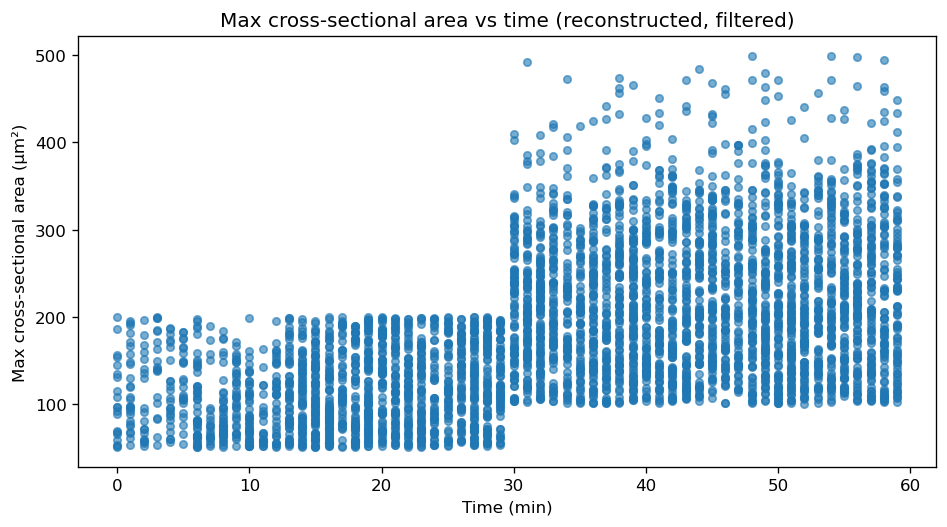

In [53]:
filtered_plot_df = plot_max_cross_sectional_area_scatter(
    best_z_df,
    pixel_size_um=0.162,
    n_fov=6,
    serpentine=True,
    early_t_max=4,
    early_min_area_um2=50,
    early_max_area_um2=200,
    late_min_area_um2=100,
    late_max_area_um2=500,
)

In [44]:



def plot_max_cross_sectional_area_scatter(
    df: pd.DataFrame,
    pixel_size_um: float,
    time_col: str = "true_time_min",
    area_px_col: str = "area_px",
    area_um2_col: str = "nucleus_area_um2",
    title: str = "Max cross-sectional area vs time",
):
    if df is None or df.empty:
        print("No data to plot.")
        return

    df = df.copy()

    # --- Ensure area in µm² ---
    if area_um2_col not in df.columns:
        if area_px_col in df.columns:
            df[area_um2_col] = df[area_px_col] * (pixel_size_um ** 2)
            print(f"Converted '{area_px_col}' → '{area_um2_col}' using pixel_size_um={pixel_size_um}")
        else:
            raise ValueError(f"Missing both '{area_um2_col}' and '{area_px_col}'")

    # --- Check required columns ---
    required = [time_col, area_um2_col]
    missing = [c for c in required if c not in df.columns]
    if missing:
        raise ValueError(f"Missing required columns: {missing}")

    plot_df = df[[time_col, area_um2_col]].dropna()

    # --- Plot ---
    plt.figure(figsize=(8, 4.5))
    plt.scatter(
        plot_df[time_col],
        plot_df[area_um2_col],
        s=20,
        alpha=0.6,
    )

    plt.xlabel("Time (min)")
    plt.ylabel("Max cross-sectional area (µm²)")
    plt.title(title)
    plt.tight_layout()
    plt.show()

Converted 'area_px' → 'nucleus_area_um2' using pixel_size_um=0.162


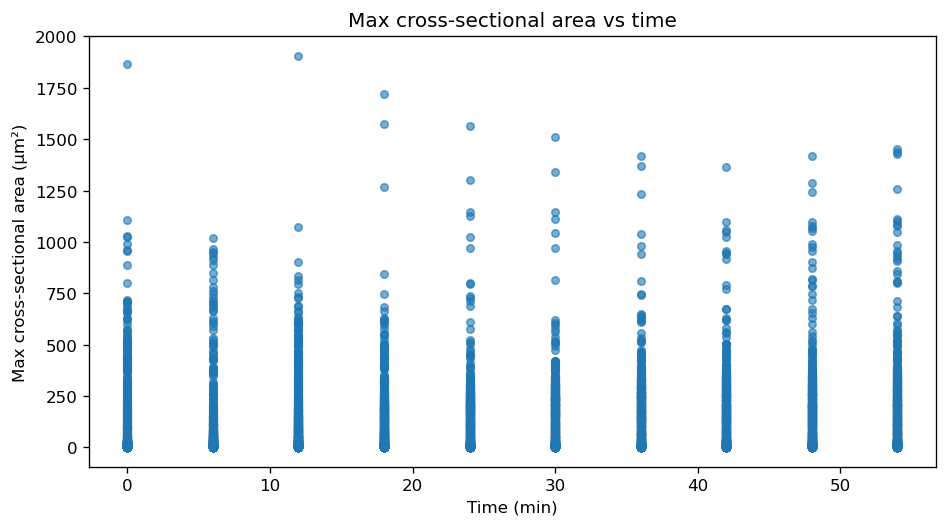

In [45]:
plot_max_cross_sectional_area_scatter(
    best_z_df,
    pixel_size_um=0.162  # <-- your actual value
)

In [31]:
print("Columns:")
print(best_z_df.columns.tolist())

if "true_time_min" in best_z_df.columns:
    print("\nUnique true_time_min values:")
    print(sorted(best_z_df["true_time_min"].dropna().unique())[:100])
    print("Count:", best_z_df["true_time_min"].nunique())

if "t" in best_z_df.columns:
    print("\nUnique t values:")
    print(sorted(best_z_df["t"].dropna().unique())[:100])
    print("Count:", best_z_df["t"].nunique())

Columns:
['t', 'z', 'label', 'centroid_x_px', 'centroid_y_px', 'area_px', 'bbox_min_row', 'bbox_min_col', 'bbox_max_row', 'bbox_max_col', 'nucleus_3d_id', 'true_time_min']

Unique true_time_min values:
[0.0, 6.0, 12.0, 18.0, 24.0, 30.0, 36.0, 42.0, 48.0, 54.0]
Count: 10

Unique t values:
[0, 1, 2, 3, 4, 5, 6, 7, 8, 9]
Count: 10


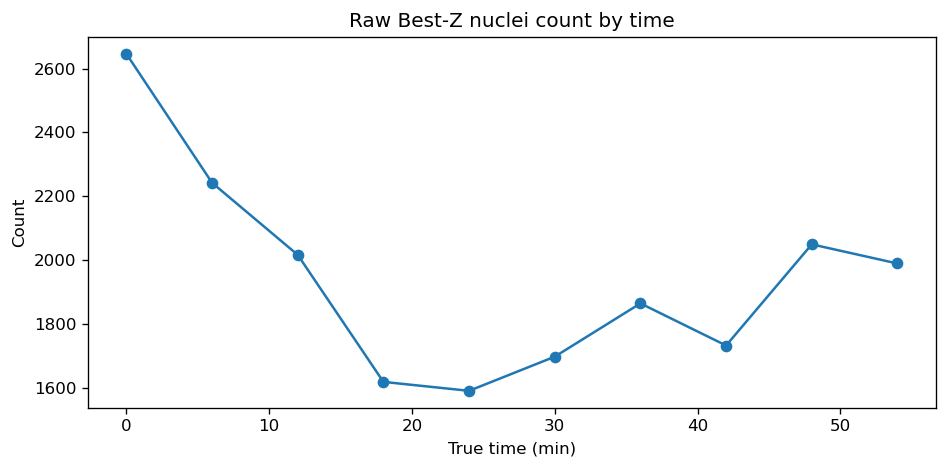

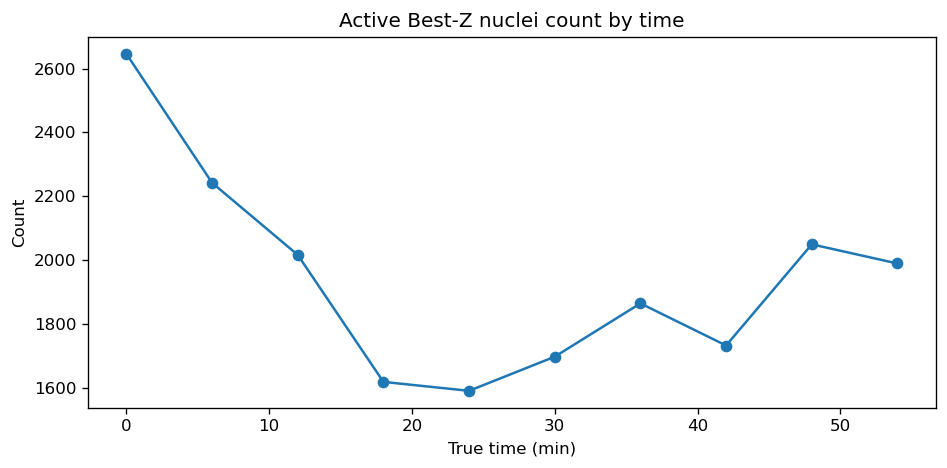

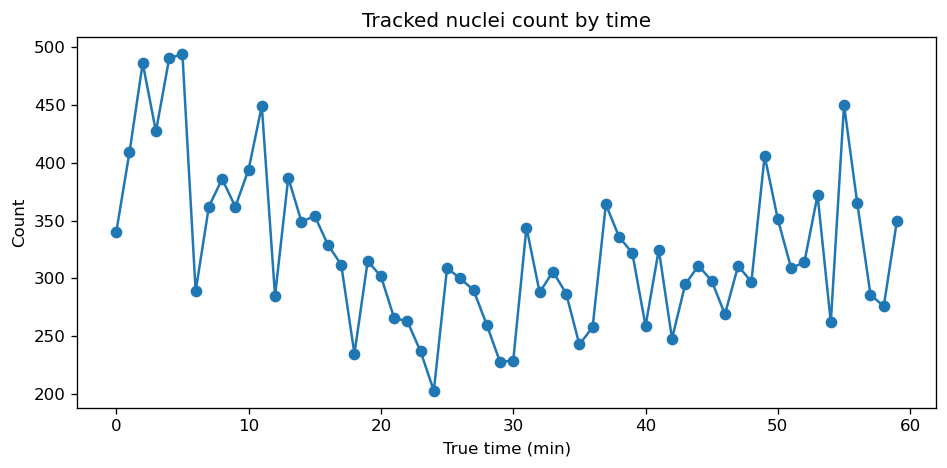

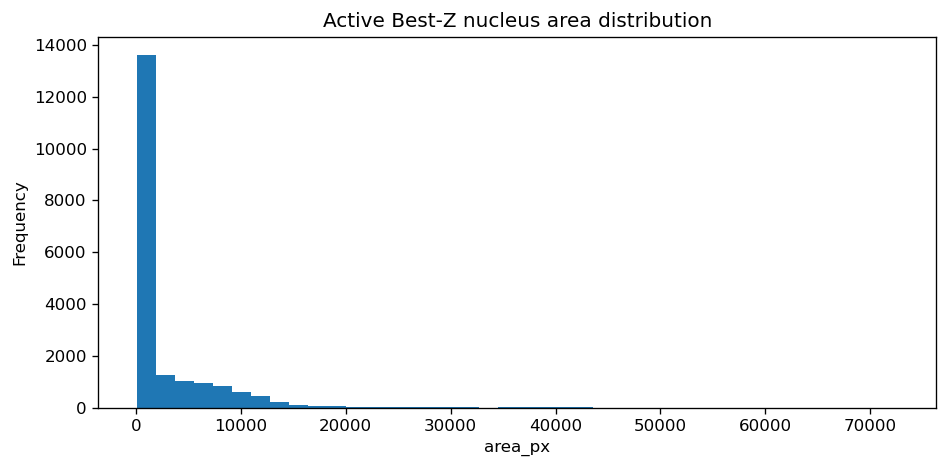

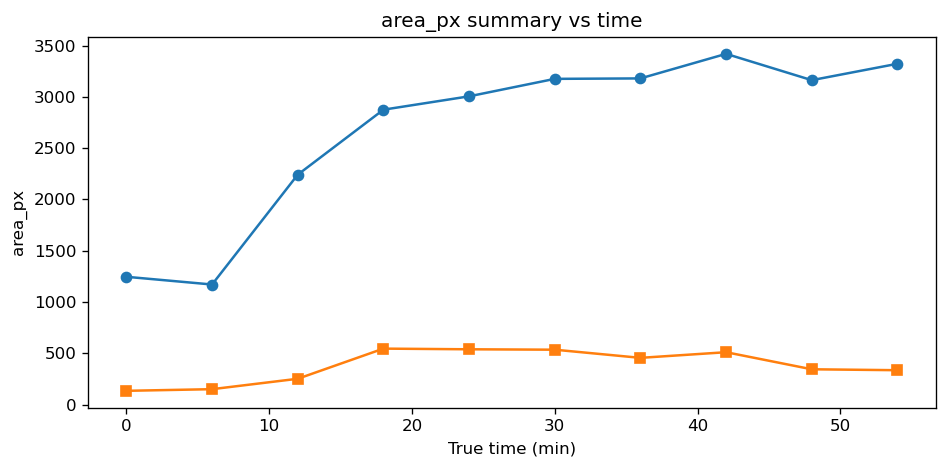

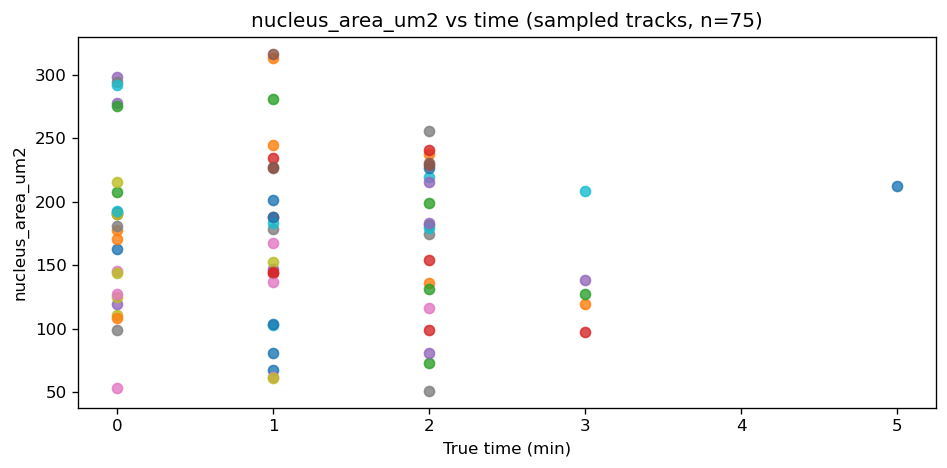

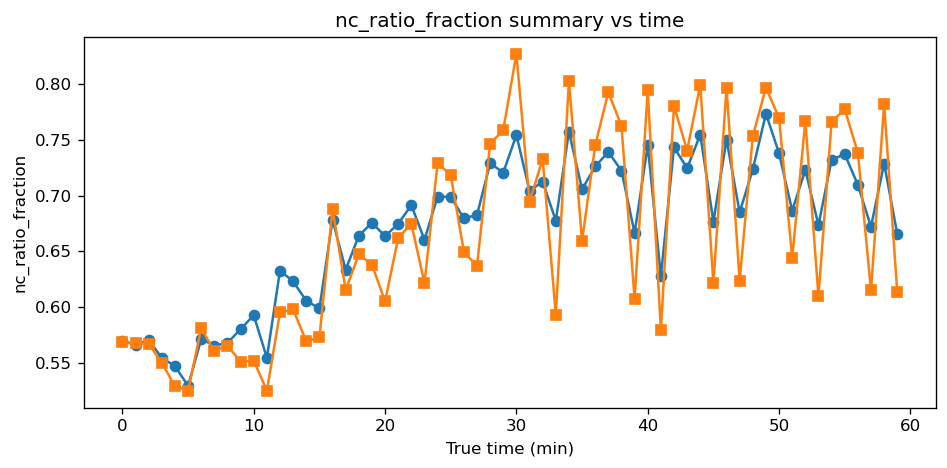

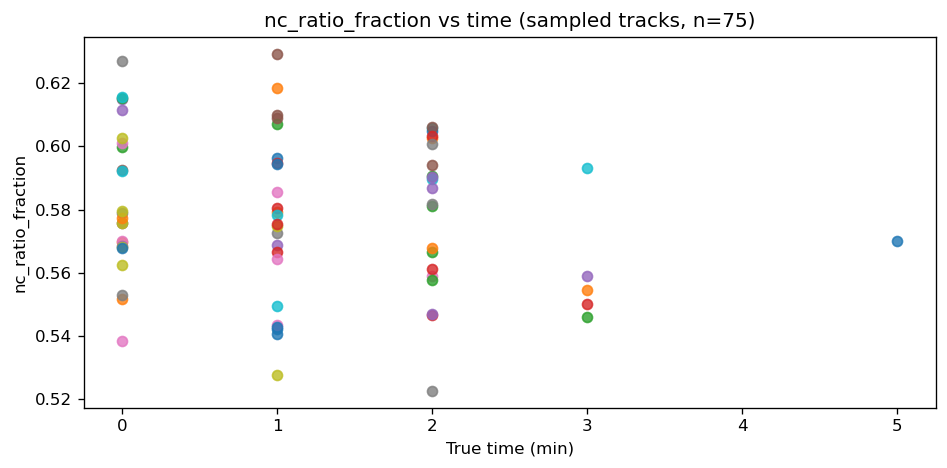

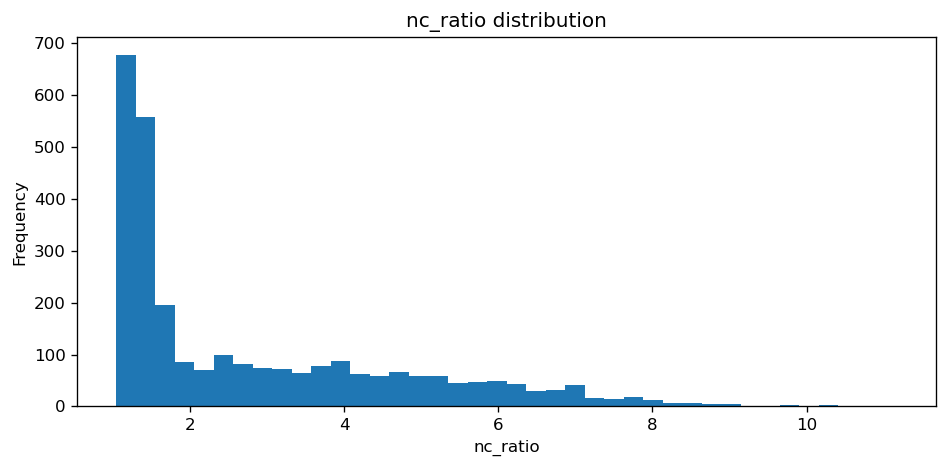

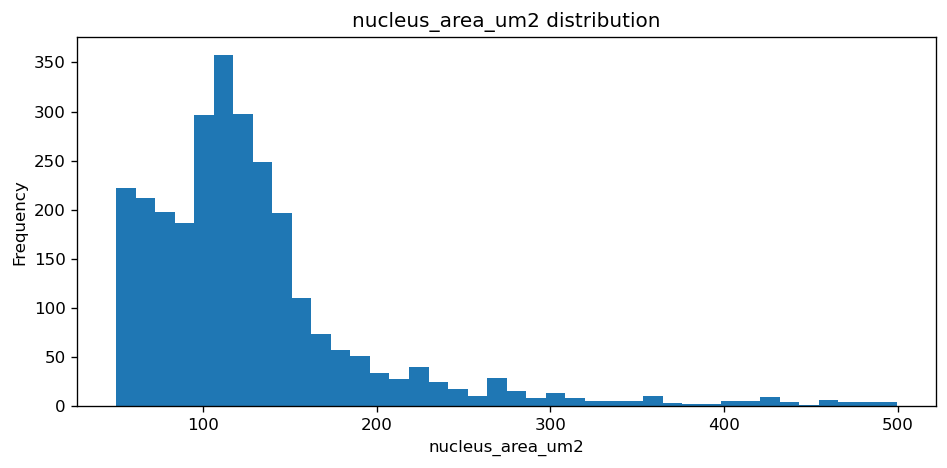

In [17]:
plot_counts_by_time(best_z_raw_df, "Raw Best-Z nuclei count by time")
plot_counts_by_time(best_z_df, "Active Best-Z nuclei count by time")
plot_counts_by_time(tracked_df, "Tracked nuclei count by time")

plot_area_distribution(best_z_df, area_col="nucleus_area_um2" if best_z_df is not None and "nucleus_area_um2" in best_z_df.columns else "area_px", title="Active Best-Z nucleus area distribution")
plot_area_summary_vs_time(best_z_df)
plot_area_vs_time(halo_df if halo_df is not None else tracked_df)

if halo_df is not None:
    plot_nc_summary_vs_time(halo_df, y_col="nc_ratio_fraction")
    plot_nc_vs_time(halo_df, y_col="nc_ratio_fraction")
    if "nc_ratio" in halo_df.columns:
        plot_metric_histogram(halo_df, "nc_ratio")
    if "nucleus_area_um2" in halo_df.columns:
        plot_metric_histogram(halo_df, "nucleus_area_um2")

## 9. QC overlay plotting

This works best if you also provide the local raw image path.  
Without the raw image, you can still inspect masks directly in napari.

In [18]:

def choose_z_for_time(mask_4d: np.ndarray, t_idx: int, mode: str = "max_mask") -> int:
    z_count = mask_4d.shape[1]
    if mode == "middle":
        return z_count // 2
    if mode == "max_mask":
        z_sums = mask_4d[t_idx].reshape(z_count, -1).sum(axis=1)
        return int(np.argmax(z_sums))
    raise ValueError("mode must be 'middle' or 'max_mask'")

def plot_raw_and_mask_overlay(raw_5d: np.ndarray, mask_4d: np.ndarray, channel_index: int, timepoints=None, z_mode="max_mask", max_cols=4):
    if raw_5d is None:
        print("Raw image not loaded.")
        return
    if mask_4d is None:
        print("Mask not loaded.")
        return

    T = raw_5d.shape[0]
    if timepoints is None:
        n_show = min(T, 6)
        timepoints = np.linspace(0, T - 1, n_show, dtype=int).tolist()

    n_panels = len(timepoints)
    n_cols = min(max_cols, n_panels)
    n_rows = int(np.ceil(n_panels / n_cols))

    fig, axes = plt.subplots(n_rows, n_cols, figsize=(4 * n_cols, 4 * n_rows))
    axes = np.atleast_1d(axes).ravel()

    for ax, t_idx in zip(axes, timepoints):
        z_idx = choose_z_for_time(mask_4d, t_idx, mode=z_mode)
        raw_plane = normalize_image(raw_5d[t_idx, z_idx, channel_index])
        mask_plane = mask_4d[t_idx, z_idx] > 0

        ax.imshow(raw_plane, cmap="gray")
        ax.imshow(mask_plane, alpha=0.35)
        ax.set_title(f"t={t_idx}, z={z_idx}")
        ax.axis("off")

    for ax in axes[n_panels:]:
        ax.axis("off")

    plt.tight_layout()
    plt.show()

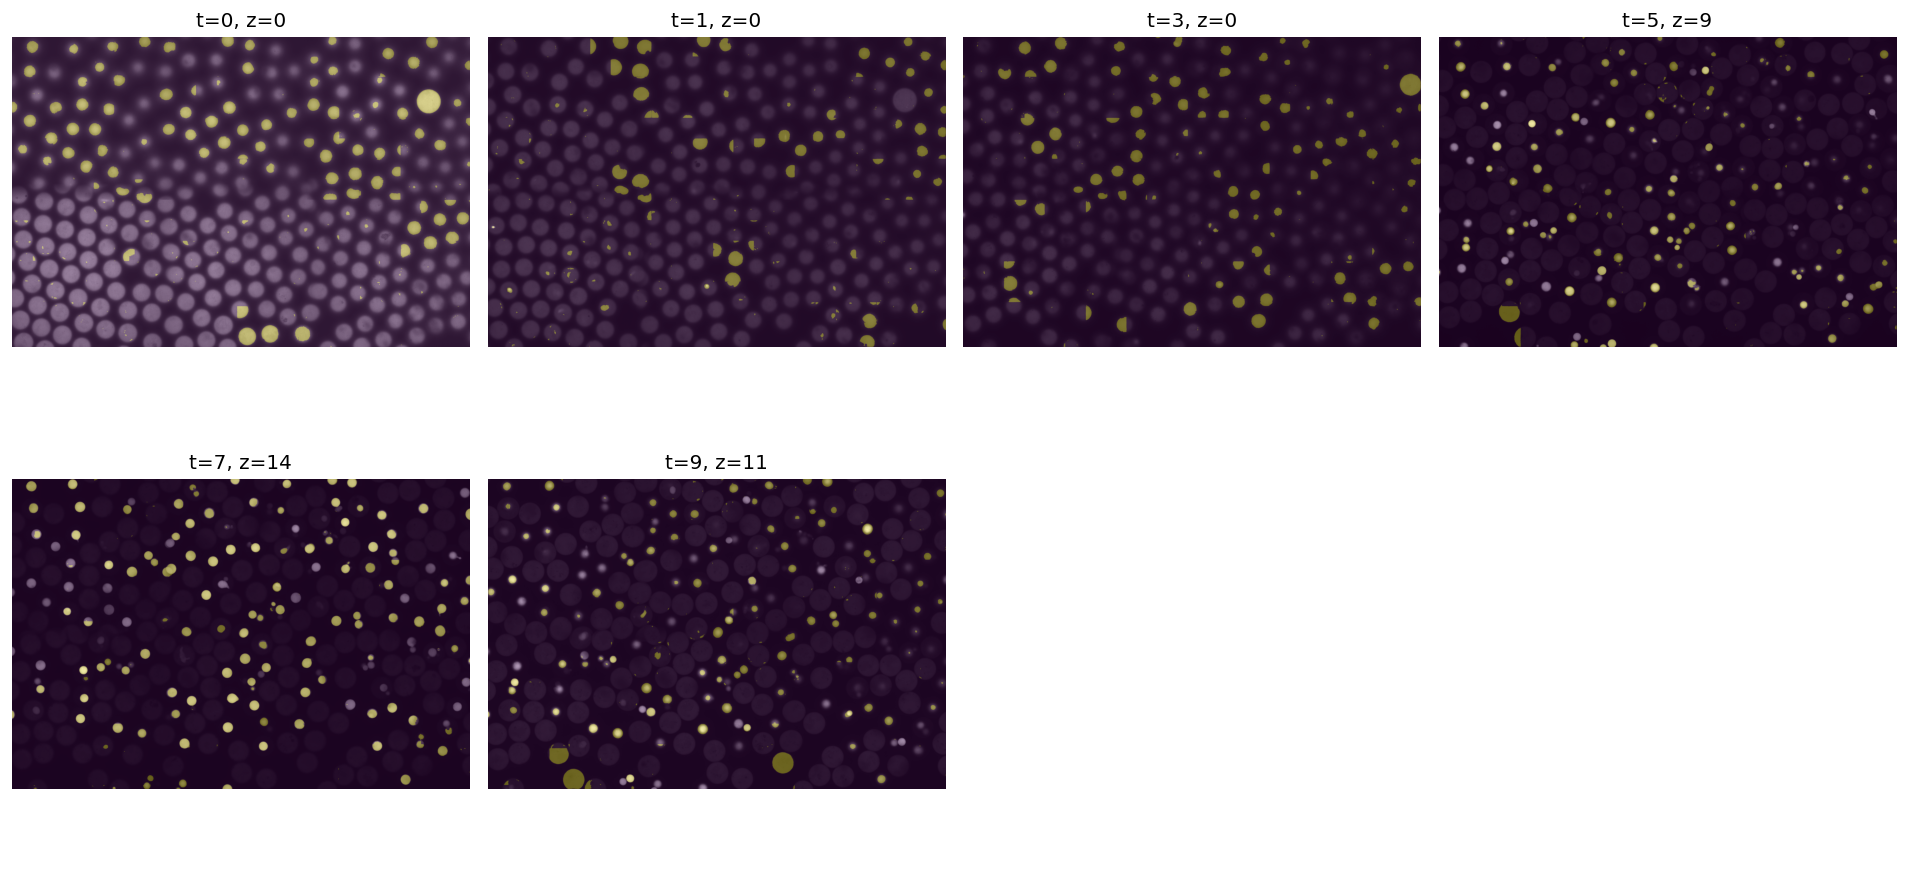

In [19]:

# Example overlay call if raw image is available:
if raw_img is not None and mask_arrays["nucleus_instance"] is not None:
    plot_raw_and_mask_overlay(
        raw_5d=raw_img,
        mask_4d=mask_arrays["nucleus_instance"],
        channel_index=int(config.get("nuclear_channel_index", 1)),
        z_mode="max_mask"
    )
else:
    print("Skipping overlay plot because raw image or nucleus instance mask is missing.")

## 10. Napari viewer

This viewer will try to load:

- raw image (if you supplied `RAW_IMAGE_PATH`)
- segmentation class labels
- segmentation connected-component labels
- nucleus instance labels
- droplet instance labels
- probability map, if it exists
- point layers from the exported tables

In [54]:

def table_to_napari_points(df: pd.DataFrame, use_best_z_only=True):
    if df is None or df.empty:
        return None, None

    required = {"t", "z", "centroid_y_px", "centroid_x_px"}
    if not required.issubset(df.columns):
        return None, None

    pts_df = df.copy()
    if use_best_z_only and "best_z" in pts_df.columns and "z" in pts_df.columns:
        pts_df = pts_df[pts_df["z"] == pts_df["best_z"]]

    points = pts_df[["t", "z", "centroid_y_px", "centroid_x_px"]].to_numpy(dtype=float)
    return points, pts_df

def open_portable_bundle_in_napari(
    raw_img=None,
    seg_class=None,
    seg_label=None,
    nucleus_instance=None,
    droplet_instance=None,
    prob_map=None,
    best_z_df=None,
    tracked_df=None,
    halo_df=None,
):
    try:
        import napari
    except ImportError:
        print("napari is not installed in this environment.")
        print("Install with: pip install napari[all]")
        return None

    viewer = napari.Viewer()

    if raw_img is not None:
        viewer.add_image(raw_img, name="raw_image")

    if prob_map is not None:
        viewer.add_image(prob_map, name="segmentation_probability")

    if seg_class is not None:
        viewer.add_labels(seg_class.astype(np.int32), name="segmentation_class")

    if seg_label is not None:
        viewer.add_labels(seg_label.astype(np.int32), name="segmentation_label")

    if nucleus_instance is not None:
        viewer.add_labels(nucleus_instance.astype(np.int32), name="nucleus_instance")

    if droplet_instance is not None:
        viewer.add_labels(droplet_instance.astype(np.int32), name="droplet_instance")

    best_points, best_props = table_to_napari_points(best_z_df, use_best_z_only=False)
    if best_points is not None:
        viewer.add_points(
            best_points,
            name="best_z_centroids",
            size=8,
            properties={c: best_props[c].to_numpy() for c in best_props.columns if c not in ["centroid_x_px", "centroid_y_px"]},
        )

    tracked_points, tracked_props = table_to_napari_points(tracked_df, use_best_z_only=False)
    if tracked_points is not None:
        viewer.add_points(
            tracked_points,
            name="tracked_centroids",
            size=10,
            properties={c: tracked_props[c].to_numpy() for c in tracked_props.columns if c not in ["centroid_x_px", "centroid_y_px"]},
        )

    return viewer

In [59]:

if AUTO_OPEN_NAPARI:
    viewer = open_portable_bundle_in_napari(
        seg_class=mask_arrays["segmentation_class"],
        seg_label=mask_arrays["segmentation_label"],
        nucleus_instance=mask_arrays["nucleus_instance"],
        best_z_df=best_z_df,
        tracked_df=tracked_df,
        halo_df=halo_df,
    )

MemoryError: Unable to allocate 49.8 GiB for an array with shape (10, 20, 3, 3889, 5732) and data type int32

In [60]:
import numpy as np
import napari


def open_nuclear_only_napari(
    seg_class,
    nucleus_instance,
    t_idx: int = 0,
    show_all_z: bool = True,
    nuclear_class_index: int = 1,
):
    """
    Open a lightweight napari viewer with only:
      1) nuclear class labels
      2) nuclear ROI / instance mask

    Parameters
    ----------
    seg_class : np.ndarray
        Expected shape is either:
        - (T, Z, C, Y, X)  -> class probabilities / one-hot channels
        - (T, Z, Y, X)     -> already class labels
        - (Z, C, Y, X)     -> single timepoint class probabilities
        - (Z, Y, X)        -> single timepoint class labels

    nucleus_instance : np.ndarray
        Expected shape is either:
        - (T, Z, Y, X)
        - (Z, Y, X)

    t_idx : int
        Timepoint to display if arrays contain T.

    show_all_z : bool
        If True, display the whole Z stack for the chosen timepoint.
        If False, display only the middle Z slice.

    nuclear_class_index : int
        Class index corresponding to nucleus in the class channel stack.
        Only used if you want a binary nucleus mask from class probabilities.
    """

    # ---------- prepare nuclear class labels ----------
    nuclear_labels = None

    if seg_class is not None:
        arr = seg_class

        # Handle time dimension
        if arr.ndim == 5:  # (T, Z, C, Y, X)
            arr = arr[t_idx]
        elif arr.ndim == 4 and nucleus_instance is not None and nucleus_instance.ndim == 4:
            # likely (T, Z, Y, X)
            arr = arr[t_idx]

        # Convert class channels -> single label map
        if arr.ndim == 4:
            # could be (Z, C, Y, X) or already (T,Z,Y,X) after slicing ambiguity
            # assume channel axis if second dim is small
            if arr.shape[1] <= 10:
                nuclear_labels = np.argmax(arr, axis=1).astype(np.uint8)
            else:
                nuclear_labels = arr.astype(np.uint8)

        elif arr.ndim == 3:
            nuclear_labels = arr.astype(np.uint8)

        else:
            raise ValueError(f"Unsupported seg_class shape after slicing: {arr.shape}")

    # ---------- prepare ROI instance mask ----------
    roi_mask = None

    if nucleus_instance is not None:
        arr = nucleus_instance

        if arr.ndim == 4:   # (T, Z, Y, X)
            arr = arr[t_idx]
        elif arr.ndim == 3: # (Z, Y, X)
            pass
        else:
            raise ValueError(f"Unsupported nucleus_instance shape: {arr.shape}")

        roi_mask = arr

    # ---------- optionally reduce to one Z slice ----------
    if not show_all_z:
        if nuclear_labels is not None and nuclear_labels.ndim == 3:
            z_mid = nuclear_labels.shape[0] // 2
            nuclear_labels = nuclear_labels[z_mid]
        if roi_mask is not None and roi_mask.ndim == 3:
            z_mid = roi_mask.shape[0] // 2
            roi_mask = roi_mask[z_mid]

    # ---------- launch viewer ----------
    viewer = napari.Viewer()

    if nuclear_labels is not None:
        viewer.add_labels(nuclear_labels, name="nuclear_class_labels")

    if roi_mask is not None:
        viewer.add_labels(roi_mask, name="nuclear_roi_mask")

    return viewer

In [63]:
viewer = open_nuclear_only_napari(
    seg_class=mask_arrays["segmentation_class"],
    nucleus_instance=mask_arrays["nucleus_instance"],
    t_idx=9,
    show_all_z=True,
    nuclear_class_index=1,
)

## 11. Useful one-liners

Uncomment what you need.

In [ ]:

# Open napari manually
# viewer = open_portable_bundle_in_napari(
#     raw_img=raw_img,
#     seg_class=mask_arrays["segmentation_class"],
#     seg_label=mask_arrays["segmentation_label"],
#     nucleus_instance=mask_arrays["nucleus_instance"],
#     droplet_instance=mask_arrays["droplet_instance"],
#     prob_map=mask_arrays["segmentation_prob"],
#     best_z_df=best_z_df,
#     tracked_df=tracked_df,
# )

# Inspect one table in detail
# display(halo_df.sort_values(["track_id", "true_time_min"]))

# Save a quick filtered CSV locally
# halo_df.query("nucleus_area_um2 > 100").to_csv("filtered_halo_analysis.csv", index=False)

## 12. Interpretation notes

### ROI handling
The exported **instance masks** act as your ROI layer in napari:
- `nucleus_instance_hyperstack.tif`
- `droplet_instance_hyperstack.tif`

Each non-zero integer is a unique object label.

### Probability maps
If a probability hyperstack was exported later, this notebook will detect it automatically as:
- `segmentation_prob_hyperstack.tif`
- or `probability_hyperstack.tif`

If neither exists, the napari viewer simply skips that layer.

In [64]:
import numpy as np
import pandas as pd


def select_best_z_by_composite_score(
    df: pd.DataFrame,
    group_col: str = "nucleus_3d_id",
    z_col: str = "z",
    area_col: str = "area_px",
    circularity_col: str = "circularity",
    fill_fraction_col: str = "fill_fraction",
    edge_col: str = "is_edge_touching",
    min_area_px: float = 20,
    area_weight: float = 0.45,
    circularity_weight: float = 0.25,
    fill_fraction_weight: float = 0.30,
    edge_penalty: float = 1.0,
) -> pd.DataFrame:
    """
    Select the best Z slice per grouped nucleus using a composite score.

    Returns one row per group_col.
    """

    if df is None or df.empty:
        return df.copy()

    required = [group_col, z_col, area_col]
    missing = [c for c in required if c not in df.columns]
    if missing:
        raise ValueError(f"Missing required columns: {missing}")

    work = df.copy()

    # Fill missing optional columns with neutral defaults
    if circularity_col not in work.columns:
        work[circularity_col] = 0.0
    if fill_fraction_col not in work.columns:
        work[fill_fraction_col] = 0.0
    if edge_col not in work.columns:
        work[edge_col] = False

    # Remove trivially tiny slices before scoring
    work = work[work[area_col] >= min_area_px].copy()
    if work.empty:
        return work

    def _normalize(series: pd.Series) -> pd.Series:
        smin = series.min()
        smax = series.max()
        if pd.isna(smin) or pd.isna(smax) or smax == smin:
            return pd.Series(np.zeros(len(series)), index=series.index)
        return (series - smin) / (smax - smin)

    selected_rows = []

    for nucleus_id, g in work.groupby(group_col, dropna=False):
        g = g.copy()

        # Normalize within each 3D object so the score compares slices within that object
        g["area_norm"] = _normalize(g[area_col].astype(float))
        g["circ_norm"] = _normalize(g[circularity_col].astype(float))
        g["fill_norm"] = _normalize(g[fill_fraction_col].astype(float))

        g["edge_penalty_val"] = g[edge_col].astype(float) * edge_penalty

        g["z_score"] = (
            area_weight * g["area_norm"]
            + circularity_weight * g["circ_norm"]
            + fill_fraction_weight * g["fill_norm"]
            - g["edge_penalty_val"]
        )

        # Tie-breakers:
        # 1) highest score
        # 2) highest area
        # 3) highest circularity
        g = g.sort_values(
            by=["z_score", area_col, circularity_col],
            ascending=[False, False, False]
        )

        selected_rows.append(g.iloc[0])

    best_z_df = pd.DataFrame(selected_rows).reset_index(drop=True)
    return best_z_df

In [65]:
def add_fill_fraction(df: pd.DataFrame) -> pd.DataFrame:
    df = df.copy()

    needed = ["bbox_min_row", "bbox_min_col", "bbox_max_row", "bbox_max_col", "area_px"]
    missing = [c for c in needed if c not in df.columns]
    if missing:
        raise ValueError(f"Missing columns for fill_fraction: {missing}")

    bbox_height = (df["bbox_max_row"] - df["bbox_min_row"]).clip(lower=1)
    bbox_width = (df["bbox_max_col"] - df["bbox_min_col"]).clip(lower=1)
    bbox_area = bbox_height * bbox_width

    df["bbox_area_px"] = bbox_area
    df["fill_fraction"] = df["area_px"] / bbox_area

    return df

In [66]:
def select_best_z_by_composite_score_with_solidity(
    df: pd.DataFrame,
    group_col: str = "nucleus_3d_id",
    z_col: str = "z",
    area_col: str = "area_px",
    circularity_col: str = "circularity",
    fill_fraction_col: str = "fill_fraction",
    solidity_col: str = "solidity",
    edge_col: str = "is_edge_touching",
    min_area_px: float = 20,
):
    df = df.copy()

    if fill_fraction_col not in df.columns:
        df = add_fill_fraction(df)

    if solidity_col not in df.columns:
        df[solidity_col] = 0.0
    if circularity_col not in df.columns:
        df[circularity_col] = 0.0
    if edge_col not in df.columns:
        df[edge_col] = False

    def _normalize(series: pd.Series) -> pd.Series:
        smin = series.min()
        smax = series.max()
        if smax == smin:
            return pd.Series(np.zeros(len(series)), index=series.index)
        return (series - smin) / (smax - smin)

    out = []
    for _, g in df.groupby(group_col, dropna=False):
        g = g[g[area_col] >= min_area_px].copy()
        if g.empty:
            continue

        g["area_norm"] = _normalize(g[area_col].astype(float))
        g["circ_norm"] = _normalize(g[circularity_col].astype(float))
        g["fill_norm"] = _normalize(g[fill_fraction_col].astype(float))
        g["solidity_norm"] = _normalize(g[solidity_col].astype(float))

        g["z_score"] = (
            0.40 * g["area_norm"]
            + 0.20 * g["circ_norm"]
            + 0.20 * g["fill_norm"]
            + 0.20 * g["solidity_norm"]
            - 1.00 * g[edge_col].astype(float)
        )

        g = g.sort_values(
            by=["z_score", area_col, circularity_col],
            ascending=[False, False, False]
        )
        out.append(g.iloc[0])

    return pd.DataFrame(out).reset_index(drop=True)

In [67]:
grouped_z_df = add_fill_fraction(grouped_z_df)

best_z_df = select_best_z_by_composite_score(
    grouped_z_df,
    group_col="nucleus_3d_id",
    z_col="z",
    area_col="area_px",
    circularity_col="circularity",
    fill_fraction_col="fill_fraction",
    edge_col="is_edge_touching",
    min_area_px=20,
)

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


def add_fill_fraction(df: pd.DataFrame) -> pd.DataFrame:
    df = df.copy()

    needed = ["bbox_min_row", "bbox_min_col", "bbox_max_row", "bbox_max_col", "area_px"]
    missing = [c for c in needed if c not in df.columns]
    if missing:
        raise ValueError(f"Missing columns for fill_fraction: {missing}")

    bbox_height = (df["bbox_max_row"] - df["bbox_min_row"]).clip(lower=1)
    bbox_width = (df["bbox_max_col"] - df["bbox_min_col"]).clip(lower=1)
    bbox_area = bbox_height * bbox_width

    df["bbox_area_px"] = bbox_area
    df["fill_fraction"] = df["area_px"] / bbox_area

    return df

In [ ]:
def select_best_z_by_composite_score(
    df: pd.DataFrame,
    group_col: str = "nucleus_3d_id",
    z_col: str = "z",
    area_col: str = "area_px",
    circularity_col: str = "circularity",
    fill_fraction_col: str = "fill_fraction",
    edge_col: str = "is_edge_touching",
    min_area_px: float = 20,
    area_weight: float = 0.45,
    circularity_weight: float = 0.25,
    fill_fraction_weight: float = 0.30,
    edge_penalty: float = 1.0,
) -> pd.DataFrame:
    if df is None or df.empty:
        return df.copy()

    required = [group_col, z_col, area_col]
    missing = [c for c in required if c not in df.columns]
    if missing:
        raise ValueError(f"Missing required columns: {missing}")

    work = df.copy()

    if circularity_col not in work.columns:
        work[circularity_col] = 0.0
    if fill_fraction_col not in work.columns:
        work[fill_fraction_col] = 0.0
    if edge_col not in work.columns:
        work[edge_col] = False

    work = work[work[area_col] >= min_area_px].copy()
    if work.empty:
        return work

    def _normalize(series: pd.Series) -> pd.Series:
        smin = series.min()
        smax = series.max()
        if pd.isna(smin) or pd.isna(smax) or smax == smin:
            return pd.Series(np.zeros(len(series)), index=series.index)
        return (series - smin) / (smax - smin)

    selected_rows = []

    for nucleus_id, g in work.groupby(group_col, dropna=False):
        g = g.copy()

        g["area_norm"] = _normalize(g[area_col].astype(float))
        g["circ_norm"] = _normalize(g[circularity_col].astype(float))
        g["fill_norm"] = _normalize(g[fill_fraction_col].astype(float))
        g["edge_penalty_val"] = g[edge_col].astype(float) * edge_penalty

        g["z_score"] = (
            area_weight * g["area_norm"]
            + circularity_weight * g["circ_norm"]
            + fill_fraction_weight * g["fill_norm"]
            - g["edge_penalty_val"]
        )

        g = g.sort_values(
            by=["z_score", area_col, circularity_col],
            ascending=[False, False, False]
        )

        selected_rows.append(g.iloc[0])

    return pd.DataFrame(selected_rows).reset_index(drop=True)

In [68]:
def plot_selected_best_z_results(
    df: pd.DataFrame,
    pixel_size_um: float,
    n_fov: int = 6,
    serpentine: bool = True,
    area_px_col: str = "area_px",
    area_um2_col: str = "nucleus_area_um2",
    title: str = "Best-Z selected max cross-sectional area vs time",
):
    if df is None or df.empty:
        print("No data to plot.")
        return df

    out = df.copy()

    if area_um2_col not in out.columns:
        if area_px_col not in out.columns:
            raise ValueError(f"Missing both '{area_um2_col}' and '{area_px_col}'")
        out[area_um2_col] = out[area_px_col] * (pixel_size_um ** 2)

    if "t" not in out.columns:
        raise ValueError("Missing required column 't'")
    if "centroid_x_px" not in out.columns:
        raise ValueError("Missing required column 'centroid_x_px'")

    max_x = out["centroid_x_px"].max()
    fov_width = max_x / n_fov

    out["fov_id"] = (out["centroid_x_px"] // fov_width).astype(int)
    out["fov_id"] = out["fov_id"].clip(0, n_fov - 1)

    if serpentine:
        reverse_mask = out["t"] % 2 == 1
        out.loc[reverse_mask, "fov_id"] = (n_fov - 1) - out.loc[reverse_mask, "fov_id"]

    out["true_time_min"] = out["t"] * n_fov + out["fov_id"]

    plt.figure(figsize=(8, 4.5))
    plt.scatter(
        out["true_time_min"],
        out[area_um2_col],
        s=20,
        alpha=0.6,
    )
    plt.xlabel("Time (min)")
    plt.ylabel("Max cross-sectional area (µm²)")
    plt.title(title)
    plt.tight_layout()
    plt.show()

    return out

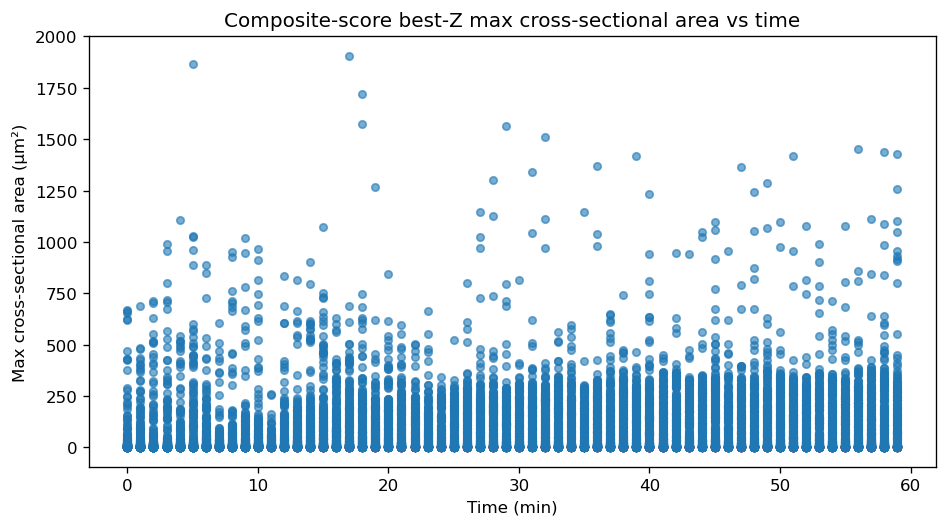

In [69]:
grouped_z_df = add_fill_fraction(grouped_z_df)

best_z_new_df = select_best_z_by_composite_score(
    grouped_z_df,
    group_col="nucleus_3d_id",
    z_col="z",
    area_col="area_px",
    circularity_col="circularity",
    fill_fraction_col="fill_fraction",
    edge_col="is_edge_touching",
    min_area_px=20,
)

best_z_new_df = plot_selected_best_z_results(
    best_z_new_df,
    pixel_size_um=0.162,
    n_fov=6,
    serpentine=True,
    title="Composite-score best-Z max cross-sectional area vs time",
)

In [ ]:
check_cols = [
    "circularity",
    "fill_fraction",
    "is_edge_touching",
    "solidity",
    "extent"
]

for c in check_cols:
    print(c, c in grouped_z_df.columns)

In [ ]:
z_counts = grouped_z_df[grouped_z_df["t"] == 5].groupby("z").size()

plt.figure(figsize=(6,4))
plt.plot(z_counts.index, z_counts.values, marker="o")
plt.xlabel("Z")
plt.ylabel("Number of grouped objects")
plt.title("Objects per Z at t=5")
plt.tight_layout()
plt.show()

In [ ]:
plot_df = grouped_z_df[grouped_z_df["t"] == 5].copy()
plot_df["area_um2"] = plot_df["area_px"] * (0.162 ** 2)

plt.figure(figsize=(7,4))
for z, g in plot_df.groupby("z"):
    plt.scatter([z] * len(g), g["area_um2"], s=8, alpha=0.4)

plt.xlabel("Z")
plt.ylabel("Area (µm²)")
plt.title("Per-slice object areas at t=5")
plt.tight_layout()
plt.show()